In [3]:
import torch

In [1]:
from pathlib import Path
import shutil
from collections import Counter

src_dir = Path("./confirmed_fronts")

dst_dir = Path("./colored_dataset")
dst_dir.mkdir(parents=True, exist_ok=True)

color_counter = Counter()
total_images = 0
bad_files = []

for img_path in src_dir.rglob("*"):
    if not img_path.is_file():
        continue
        
    filename = img_path.name
    parts = filename.split("$$")
    color = parts[3].lower()

    if not color:
        bad_files.appen(str(img_path))
        continue
    
    color_dir = dst_dir / color
    color_dir.mkdir(parents=True, exist_ok=True)

    shutil.copy2(img_path, color_dir / img_path.name)
    color_counter[color] += 1
    total_images += 1

if bad_files:
    print("Bad files:")
    for file in bad_files:
        print(file)

threshold = total_images * 0.01
print(f"Threshold (1%): {threshold:.0f}\n")

for color, count in sorted(color_counter.items(), key=lambda x: x[1], reverse=True):
    if count < threshold:
        print(f"[DELETE] {color}: {count}")
        shutil.rmtree(dst_dir.joinpath(color))
    else:
        print(f"[KEEP]   {color}: {count}")


Threshold (1%): 618

[KEEP]   black: 14317
[KEEP]   grey: 9474
[KEEP]   white: 9395
[KEEP]   blue: 8483
[KEEP]   silver: 7770
[KEEP]   red: 6095
[KEEP]   unlisted: 1516
[KEEP]   brown: 911
[KEEP]   green: 777
[KEEP]   yellow: 667
[DELETE] beige: 600
[DELETE] orange: 559
[DELETE] purple: 362
[DELETE] bronze: 329
[DELETE] gold: 217
[DELETE] multicolour: 196
[DELETE] pink: 87
[DELETE] turquoise: 26
[DELETE] maroon: 26
[DELETE] burgundy: 9
[DELETE] magenta: 9
[DELETE] navy: 1
[DELETE] indigo: 1


In [4]:
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset, random_split

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_full_dataset = datasets.ImageFolder("./colored_dataset", transform=train_transform)
val_full_dataset = datasets.ImageFolder("./colored_dataset", transform=val_transform)
dataset_size = len(train_full_dataset)


train_size = int(0.7 * dataset_size)
val_size = int(0.15 * dataset_size)
test_size = dataset_size - train_size - val_size

train_indices, val_indices, test_indices = random_split(
    range(dataset_size),
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_dataset = Subset(train_full_dataset, train_indices.indices)
val_dataset = Subset(val_full_dataset, val_indices.indices)
test_dataset = Subset(val_full_dataset, test_indices.indices)

train_loader = DataLoader(
    train_dataset, 
    batch_size=16, 
    shuffle=True,
    num_workers=4
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=16, 
    shuffle=False,
    num_workers=4
)
test_loader = DataLoader(
    test_dataset, 
    batch_size=16, 
    shuffle=False,
    num_workers=4
)

print("Classes:", dataset_size)
print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

Classes: 59405
Train: 41583
Val: 8910
Test: 8912


In [5]:
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=3, stride=stride, padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(
            out_channels, out_channels,
            kernel_size=3, stride=1, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels, out_channels,
                    kernel_size=1, stride=stride, bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out += identity
        out = self.relu(out)

        return out


class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes):
        super().__init__()

        self.in_channels = 64

        self.conv1 = nn.Conv2d(
            in_channels=3, out_channels=64,
            kernel_size=7, stride=2, padding=3, bias=False
        )
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(block, 64,  layers[0], stride=1)
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, blocks, stride):
        layers = []

        layers.append(block(self.in_channels, out_channels, stride))
        self.in_channels = out_channels * block.expansion

        for _ in range(1, blocks):
            layers.append(block(self.in_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)     # [B, 64, 112, 112]
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)   # [B, 64, 56, 56]

        x = self.layer1(x)    # [B, 64, 56, 56]
        x = self.layer2(x)    # [B, 128, 28, 28]
        x = self.layer3(x)    # [B, 256, 14, 14]
        x = self.layer4(x)    # [B, 512, 7, 7]

        x = self.avgpool(x)   # [B, 512, 1, 1]
        x = torch.flatten(x, 1)
        x = self.fc(x)        # [B, num_classes]

        return x


def ResNet18(num_classes=23):
    return ResNet(BasicBlock, [2, 2, 2, 2], num_classes=num_classes)

In [73]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("CUDA available:", torch.cuda.is_available())
print("Device:", device)
print(torch.cuda.get_device_name(0))

num_classes = len(full_dataset.classes)
resnet18s = ResNet18(num_classes=num_classes).to(device)

print(resnet18s)

CUDA available: True
Device: cuda
NVIDIA GeForce GTX 1650 Ti with Max-Q Design
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): Batch

In [6]:
from sklearn.metrics import f1_score

@torch.no_grad()
def evaluate(model, loader, criterion, device, desc="Validation"):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    for images, labels in tqdm(loader, desc=desc, leave=False):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")

    return epoch_loss, epoch_f1

In [7]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

In [8]:
def train_model(model, model_name, optimizer, train_loader, val_loader, test_loader, device, num_epochs=15):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',     
        factor=0.5,      
        patience=2
    )

    best_val_f1 = 0.0
    best_model_path = f"best_{model_name}.pth"

    history = {
        "train_loss": [],
        "train_f1": [],
        "val_loss": [],
        "val_f1": [],
    }

    for epoch in range(num_epochs):
        train_loss, train_f1 = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_f1 = evaluate(model, val_loader, criterion, device, desc=f"{model_name} Validation")

        history["train_loss"].append(train_loss)
        history["train_f1"].append(train_f1)
        history["val_loss"].append(val_loss)
        history["val_f1"].append(val_f1)

        print(f"\n{model_name} | Epoch [{epoch+1}/{num_epochs}]")
        print(f"Train Loss: {train_loss:.4f} | Train F1_macro: {train_f1:.4f}")
        print(f"Val   Loss: {val_loss:.4f} | Val   F1_macro: {val_f1:.4f}")

        scheduler.step(val_loss)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), best_model_path)
            print(f"Best {model_name} saved.")

    model.load_state_dict(torch.load(best_model_path, map_location=device))
    test_loss, test_f1 = evaluate(model, test_loader, criterion, device, desc=f"{model_name} Testing")

    print(f"\n{model_name} TEST:")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test F1_macro: {test_f1:.4f}")

    return model, history, best_val_f1, test_f1

In [9]:
import matplotlib.pyplot as plt


def plot_learning_curves(train_values, val_values, title="Learning Curve", metric_name="Loss"):
    epochs = range(1, len(train_values) + 1)

    plt.figure(figsize=(8, 5))
    
    plt.plot(epochs, train_values, marker='o', label=f"Train {metric_name}")
    plt.plot(epochs, val_values, marker='o', label=f"Val {metric_name}")

    plt.xlabel("Epoch")
    plt.ylabel(metric_name)
    plt.title(title)
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


resnet18_from_scratch | Epoch [1/15]
Train Loss: 1.0541 | Train F1_macro: 0.6386
Val   Loss: 0.8510 | Val   F1_macro: 0.5644
Best resnet18_from_scratch saved.



resnet18_from_scratch | Epoch [2/15]
Train Loss: 0.8174 | Train F1_macro: 0.7384
Val   Loss: 0.6806 | Val   F1_macro: 0.6193
Best resnet18_from_scratch saved.



resnet18_from_scratch | Epoch [3/15]
Train Loss: 0.7255 | Train F1_macro: 0.7729
Val   Loss: 0.6639 | Val   F1_macro: 0.6534
Best resnet18_from_scratch saved.



resnet18_from_scratch | Epoch [4/15]
Train Loss: 0.6667 | Train F1_macro: 0.7922
Val   Loss: 0.5948 | Val   F1_macro: 0.6010



resnet18_from_scratch | Epoch [5/15]
Train Loss: 0.6199 | Train F1_macro: 0.8096
Val   Loss: 0.6752 | Val   F1_macro: 0.6507


...


resnet18_from_scratch | Epoch [12/15]
Train Loss: 0.4908 | Train F1_macro: 0.8538
Val   Loss: 0.4834 | Val   F1_macro: 0.7350
Best resnet18_from_scratch saved.



resnet18_from_scratch | Epoch [13/15]
Train Loss: 0.4807 | Train F1_macro: 0.8561
Val   Loss: 0.4749 | Val   F1_macro: 0.7322



resnet18_from_scratch | Epoch [14/15]
Train Loss: 0.4725 | Train F1_macro: 0.8595
Val   Loss: 0.4822 | Val   F1_macro: 0.7355
Best resnet18_from_scratch saved.



resnet18_from_scratch | Epoch [15/15]
Train Loss: 0.4685 | Train F1_macro: 0.8620
Val   Loss: 0.4570 | Val   F1_macro: 0.7433
Best resnet18_from_scratch saved.



resnet18_from_scratch TEST:
Test Loss: 0.4612
Test F1_macro: 0.7522


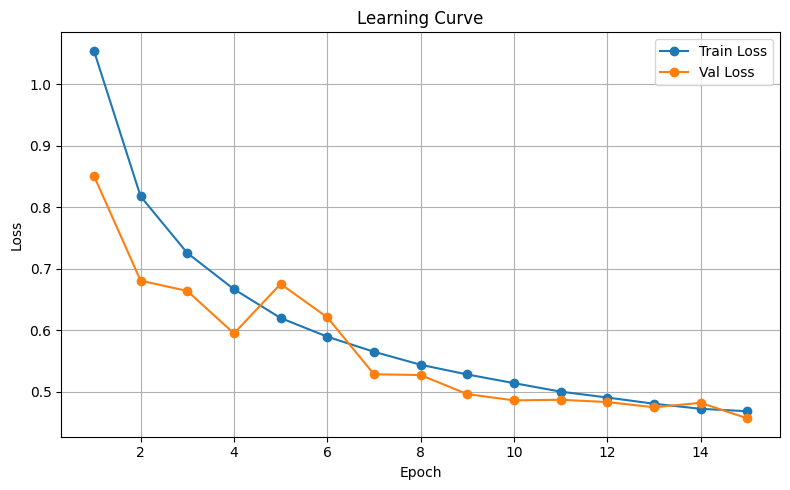

In [78]:
resnet18s_model, resnet18s_history, resnet18s_val_f1, resnet18s_test_f1 = train_model(
    resnet18s,
    "resnet18_from_scratch",
    torch.optim.Adam(
        resnet18s.parameters(),
        lr=1e-3,
        weight_decay=1e-4
    ),
    train_loader,
    val_loader,
    test_loader,
    device,
    num_epochs=15
)

plot_learning_curves(resnet18s_history['train_loss'], resnet18s_history['val_loss'], title="Learning Curve", metric_name="Loss")

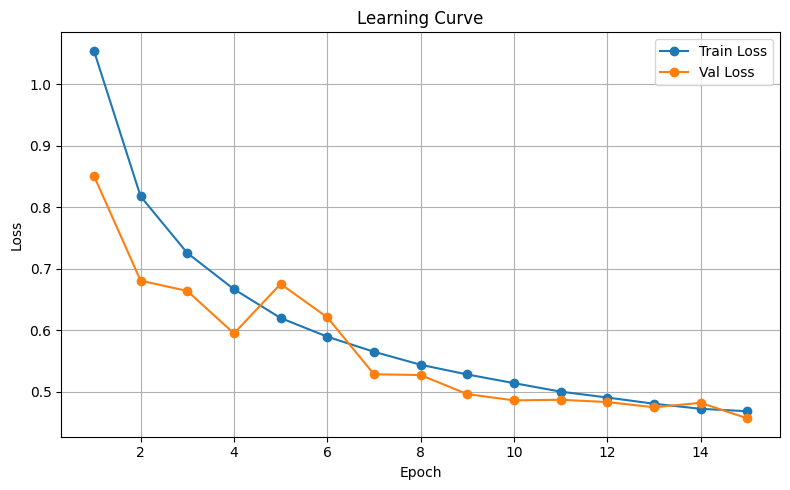

In [79]:
plot_learning_curves(resnet18s_history['train_loss'], resnet18s_history['val_loss'], title="Learning Curve", metric_name="Loss")

In [10]:
def build_efficientnet_b0(num_classes):
    weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
    model = models.efficientnet_b0(weights=weights)

    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)

    return model

In [11]:
def freeze_backbone(model):
    for param in model.parameters():
        param.requires_grad = False

    for param in model.classifier.parameters():
        param.requires_grad = True


def unfreeze_all(model):
    for param in model.parameters():
        param.requires_grad = True
    return model


efficientnet_b0 | Epoch [1/8]
Train Loss: 1.3375 | Train F1_macro: 0.5737
Val   Loss: 1.0606 | Val   F1_macro: 0.4969
Best efficientnet_b0 saved.



efficientnet_b0 | Epoch [2/8]
Train Loss: 1.0565 | Train F1_macro: 0.6479
Val   Loss: 0.9595 | Val   F1_macro: 0.5433
Best efficientnet_b0 saved.



efficientnet_b0 | Epoch [3/8]
Train Loss: 0.9929 | Train F1_macro: 0.6684
Val   Loss: 0.9078 | Val   F1_macro: 0.5645
Best efficientnet_b0 saved.



efficientnet_b0 | Epoch [4/8]
Train Loss: 0.9594 | Train F1_macro: 0.6748
Val   Loss: 0.9010 | Val   F1_macro: 0.5702
Best efficientnet_b0 saved.



efficientnet_b0 | Epoch [5/8]
Train Loss: 0.9391 | Train F1_macro: 0.6837
Val   Loss: 0.8841 | Val   F1_macro: 0.5659



efficientnet_b0 | Epoch [6/8]
Train Loss: 0.9282 | Train F1_macro: 0.6845
Val   Loss: 0.8684 | Val   F1_macro: 0.5846
Best efficientnet_b0 saved.



efficientnet_b0 | Epoch [7/8]
Train Loss: 0.9215 | Train F1_macro: 0.6868
Val   Loss: 0.8456 | Val   F1_macro: 0.5977
Best efficientnet_b0 saved.



efficientnet_b0 | Epoch [8/8]
Train Loss: 0.9065 | Train F1_macro: 0.6930
Val   Loss: 0.8585 | Val   F1_macro: 0.5883



efficientnet_b0 TEST:
Test Loss: 0.8470
Test F1_macro: 0.6178


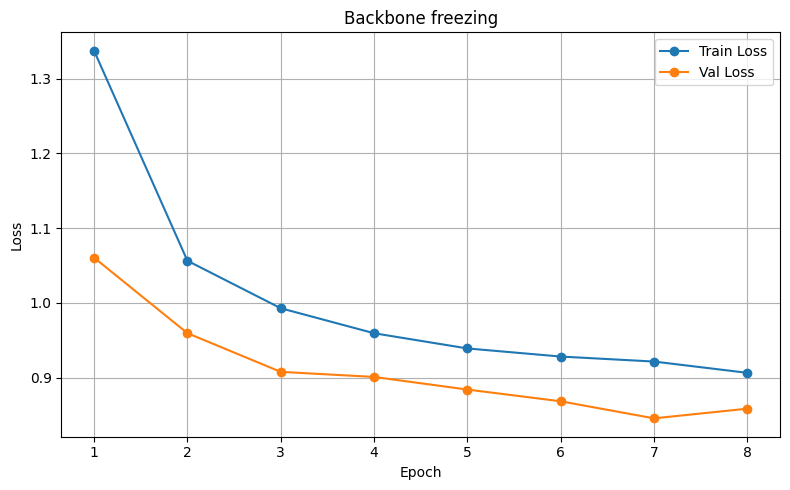


efficientnet_b0 | Epoch [1/7]
Train Loss: 0.6277 | Train F1_macro: 0.8015
Val   Loss: 0.4614 | Val   F1_macro: 0.7545
Best efficientnet_b0 saved.



efficientnet_b0 | Epoch [2/7]
Train Loss: 0.4544 | Train F1_macro: 0.8606
Val   Loss: 0.3797 | Val   F1_macro: 0.7850
Best efficientnet_b0 saved.



efficientnet_b0 | Epoch [3/7]
Train Loss: 0.3801 | Train F1_macro: 0.8871
Val   Loss: 0.3696 | Val   F1_macro: 0.7933
Best efficientnet_b0 saved.



efficientnet_b0 | Epoch [4/7]
Train Loss: 0.3286 | Train F1_macro: 0.9018
Val   Loss: 0.3582 | Val   F1_macro: 0.8028
Best efficientnet_b0 saved.



efficientnet_b0 | Epoch [5/7]
Train Loss: 0.2897 | Train F1_macro: 0.9127
Val   Loss: 0.3336 | Val   F1_macro: 0.8186
Best efficientnet_b0 saved.



efficientnet_b0 | Epoch [6/7]
Train Loss: 0.2544 | Train F1_macro: 0.9229
Val   Loss: 0.3204 | Val   F1_macro: 0.8249
Best efficientnet_b0 saved.



efficientnet_b0 | Epoch [7/7]
Train Loss: 0.2277 | Train F1_macro: 0.9280
Val   Loss: 0.3365 | Val   F1_macro: 0.8229



efficientnet_b0 TEST:
Test Loss: 0.3335
Test F1_macro: 0.8347


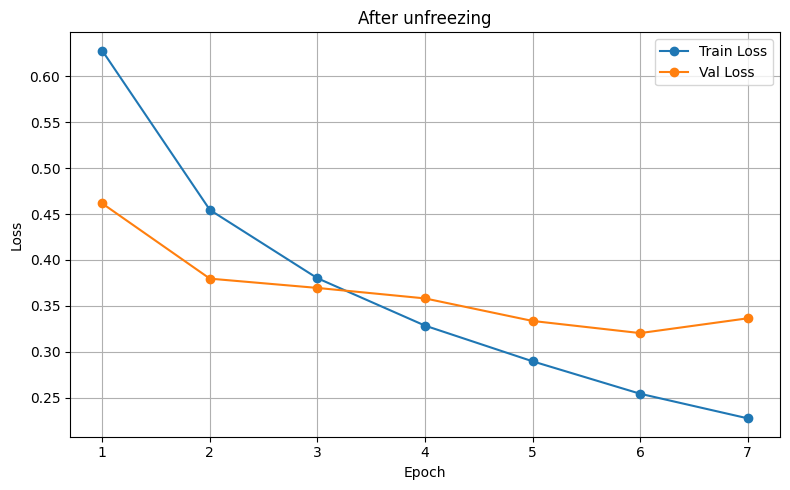

In [82]:
efficientnet_b0 = build_efficientnet_b0(num_classes)
freeze_backbone(efficientnet_b0)

efficientnet_b0, efficientnet_b0_history, efficientnet_b0_val_f1, efficientnet_b0_test_f1 = train_model(
    efficientnet_b0,
    "efficientnet_b0",
    optim.Adam(
        filter(lambda p: p.requires_grad, efficientnet_b0.parameters()),
        lr=1e-4,
        weight_decay=1e-4
    ),
    train_loader,
    val_loader,
    test_loader,
    device,
    num_epochs=8
)

plot_learning_curves(efficientnet_b0_history['train_loss'], efficientnet_b0_history['val_loss'], title="Backbone freezing", metric_name="Loss")

unfreeze_all(efficientnet_b0)

efficientnet_b0, efficientnet_b0_history, efficientnet_b0_val_f1, efficientnet_b0_test_f1 = train_model(
    efficientnet_b0,
    "efficientnet_b0",
    optim.Adam(
        efficientnet_b0.parameters(),
        lr=5e-5,
        weight_decay=1e-4
    ),
    train_loader,
    val_loader,
    test_loader,
    device,
    num_epochs=7
)

plot_learning_curves(efficientnet_b0_history['train_loss'], efficientnet_b0_history['val_loss'], title="After unfreezing", metric_name="Loss")

In [ ]:
def build_mobilenet_v3_small(num_classes):
    weights = models.MobileNet_V3_Small_Weights.IMAGENET1K_V1
    model = models.mobilenet_v3_small(weights=weights)

    in_features = model.classifier[3].in_features
    model.classifier[3] = nn.Linear(in_features, num_classes)

    return model


mobilenet_v3_small | Epoch [1/8]
Train Loss: 1.0864 | Train F1_macro: 0.6241
Val   Loss: 0.9041 | Val   F1_macro: 0.5518
Best mobilenet_v3_small saved.



mobilenet_v3_small | Epoch [2/8]
Train Loss: 0.9219 | Train F1_macro: 0.6825
Val   Loss: 0.8754 | Val   F1_macro: 0.5703
Best mobilenet_v3_small saved.



mobilenet_v3_small | Epoch [3/8]
Train Loss: 0.8809 | Train F1_macro: 0.6984
Val   Loss: 0.8312 | Val   F1_macro: 0.5925
Best mobilenet_v3_small saved.



mobilenet_v3_small | Epoch [4/8]
Train Loss: 0.8576 | Train F1_macro: 0.7061
Val   Loss: 0.7952 | Val   F1_macro: 0.6014
Best mobilenet_v3_small saved.



mobilenet_v3_small | Epoch [5/8]
Train Loss: 0.8406 | Train F1_macro: 0.7156
Val   Loss: 0.7882 | Val   F1_macro: 0.6054
Best mobilenet_v3_small saved.



mobilenet_v3_small | Epoch [6/8]
Train Loss: 0.8231 | Train F1_macro: 0.7176
Val   Loss: 0.7894 | Val   F1_macro: 0.6020



mobilenet_v3_small | Epoch [7/8]
Train Loss: 0.8132 | Train F1_macro: 0.7232
Val   Loss: 0.7970 | Val   F1_macro: 0.6176
Best mobilenet_v3_small saved.



mobilenet_v3_small | Epoch [8/8]
Train Loss: 0.7963 | Train F1_macro: 0.7286
Val   Loss: 0.7611 | Val   F1_macro: 0.6195
Best mobilenet_v3_small saved.



mobilenet_v3_small TEST:
Test Loss: 0.7550
Test F1_macro: 0.6476


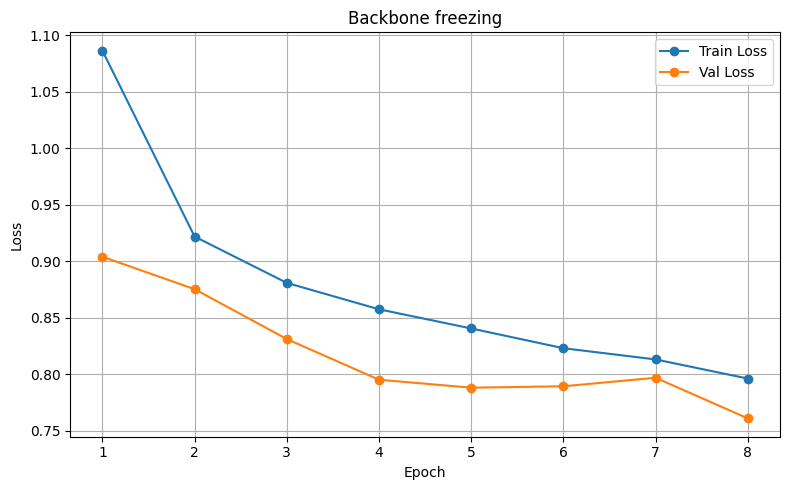


mobilenet_v3_small | Epoch [1/7]
Train Loss: 0.7016 | Train F1_macro: 0.7665
Val   Loss: 0.6109 | Val   F1_macro: 0.6874
Best mobilenet_v3_small saved.



mobilenet_v3_small | Epoch [2/7]
Train Loss: 0.6219 | Train F1_macro: 0.7981
Val   Loss: 0.5646 | Val   F1_macro: 0.7049
Best mobilenet_v3_small saved.



mobilenet_v3_small | Epoch [3/7]
Train Loss: 0.5771 | Train F1_macro: 0.8162
Val   Loss: 0.5342 | Val   F1_macro: 0.7128
Best mobilenet_v3_small saved.



mobilenet_v3_small | Epoch [4/7]
Train Loss: 0.5519 | Train F1_macro: 0.8250
Val   Loss: 0.5103 | Val   F1_macro: 0.7252
Best mobilenet_v3_small saved.



mobilenet_v3_small | Epoch [5/7]
Train Loss: 0.5253 | Train F1_macro: 0.8354
Val   Loss: 0.5052 | Val   F1_macro: 0.7321
Best mobilenet_v3_small saved.



mobilenet_v3_small | Epoch [6/7]
Train Loss: 0.5054 | Train F1_macro: 0.8441
Val   Loss: 0.4772 | Val   F1_macro: 0.7444
Best mobilenet_v3_small saved.



mobilenet_v3_small | Epoch [7/7]
Train Loss: 0.4891 | Train F1_macro: 0.8487
Val   Loss: 0.4629 | Val   F1_macro: 0.7512
Best mobilenet_v3_small saved.



mobilenet_v3_small TEST:
Test Loss: 0.4651
Test F1_macro: 0.7719


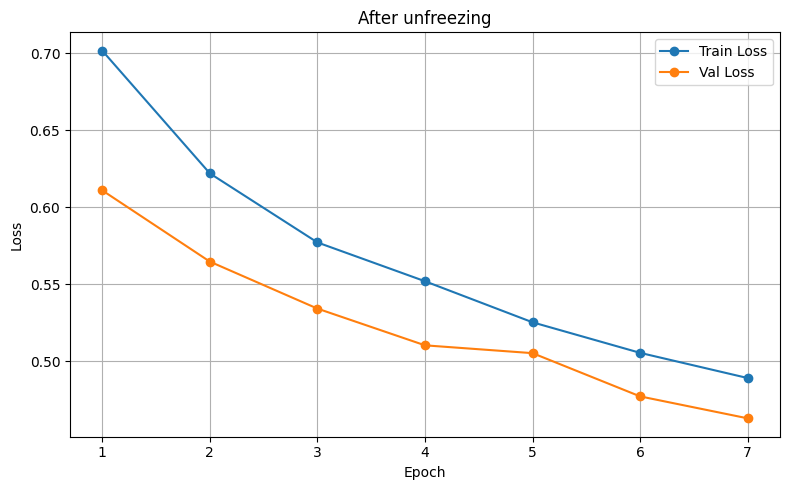

In [84]:
mobilenet_v3 = build_mobilenet_v3_small(num_classes)
freeze_backbone(mobilenet_v3)

mobilenet_v3, mobilenet_v3_history, mobilenet_v3_val_f1, mobilenet_v3_test_f1 = train_model(
    mobilenet_v3,
    "mobilenet_v3_small",
    optim.Adam(
        filter(lambda p: p.requires_grad, mobilenet_v3.parameters()),
        lr=1e-4,
        weight_decay=1e-4
    ),
    train_loader,
    val_loader,
    test_loader,
    device,
    num_epochs=8
)

plot_learning_curves(mobilenet_v3_history['train_loss'], mobilenet_v3_history['val_loss'], title="Backbone freezing", metric_name="Loss")

unfreeze_all(mobilenet_v3)

mobilenet_v3, mobilenet_v3_history, mobilenet_v3_val_f1, mobilenet_v3_test_f1 = train_model(
    mobilenet_v3,
    "mobilenet_v3_small",
    optim.Adam(
        mobilenet_v3.parameters(),
        lr=1e-5,
        weight_decay=1e-5
    ),
    train_loader,
    val_loader,
    test_loader,
    device,
    num_epochs=7
)

plot_learning_curves(mobilenet_v3_history['train_loss'], mobilenet_v3_history['val_loss'], title="After unfreezing", metric_name="Loss")

Модель:    efficientnet_b0
Файл:      best_efficientnet_b0.pth
Accuracy:  0.9069
F1_macro:  0.8337

              precision    recall  f1-score   support

       black       0.92      0.95      0.94      2170
        blue       0.93      0.89      0.91      1290
       brown       0.75      0.75      0.75       145
       green       0.94      0.86      0.90       118
        grey       0.84      0.84      0.84      1391
         red       0.97      0.99      0.98       906
      silver       0.89      0.91      0.90      1186
    unlisted       0.51      0.15      0.23       210
       white       0.94      0.99      0.96      1398
      yellow       0.87      0.98      0.92        98

    accuracy                           0.91      8912
   macro avg       0.86      0.83      0.83      8912
weighted avg       0.90      0.91      0.90      8912



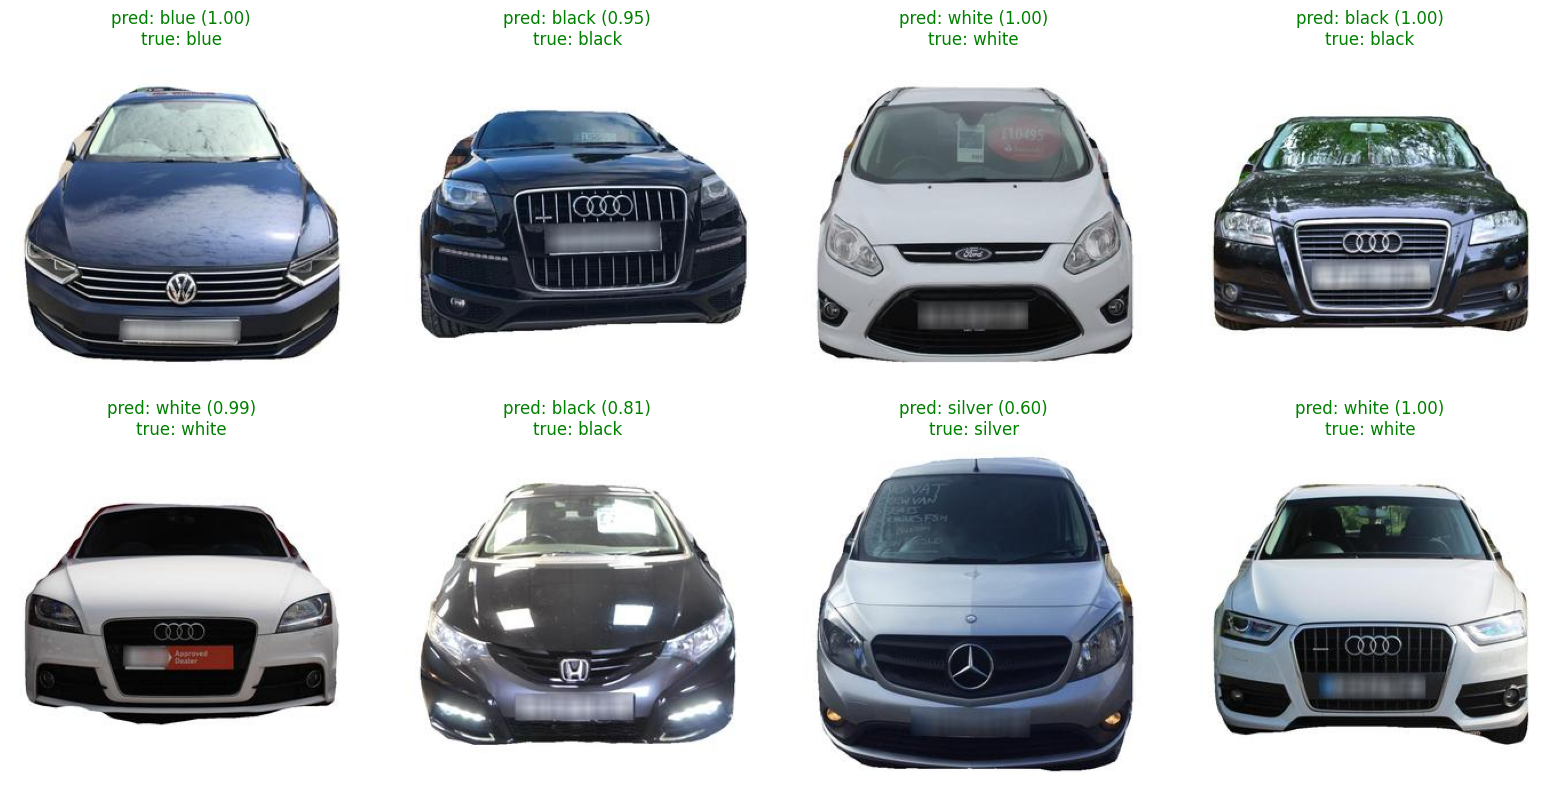

In [14]:
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from sklearn.metrics import classification_report, f1_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_names = val_full_dataset.classes
num_classes = len(class_names)

MODEL_NAME = "efficientnet_b0"
BATCH_SIZE = 16

mean = torch.tensor([0.485, 0.456, 0.406], dtype=torch.float32).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225], dtype=torch.float32).view(3, 1, 1)

model_configs = {
    "mobilenet_v3_small": {
        "builder": lambda: build_mobilenet_v3_small(num_classes),
        "weights": "best_mobilenet_v3_small.pth",
    },
    "efficientnet_b0": {
        "builder": lambda: build_efficientnet_b0(num_classes),
        "weights": "best_efficientnet_b0.pth",
    },
    "resnet18_from_scratch": {
        "builder": lambda: ResNet18(num_classes=num_classes),
        "weights": "best_resnet18_from_scratch.pth",
    },
}

cfg = model_configs[MODEL_NAME]

candidates = [
    Path(cfg["weights"]),
    Path("Lab1") / cfg["weights"],
    Path("/home/usrname/cv/Lab1") / cfg["weights"],
]

weights_path = next((p for p in candidates if p.exists()), None)
if weights_path is None:
    raise FileNotFoundError(f"Не найден файл весов: {cfg['weights']}")

model = cfg["builder"]().to(device)
model.load_state_dict(torch.load(weights_path, map_location=device))
model.eval()

def pil_to_float_tensor(image):
    image = image.convert("RGB")
    buffer = bytearray(image.tobytes())
    tensor = torch.frombuffer(buffer, dtype=torch.uint8)
    tensor = tensor.view(image.size[1], image.size[0], len(image.getbands()))
    tensor = tensor.permute(2, 0, 1).contiguous().float().div(255.0)
    return tensor

def preprocess_image(image):
    image = image.resize((224, 224))
    tensor = pil_to_float_tensor(image)
    tensor = (tensor - mean) / std
    return tensor

test_samples = [val_full_dataset.samples[idx] for idx in test_dataset.indices]

all_preds = []
all_targets = []

sample_images = []
sample_preds = []
sample_targets = []
sample_scores = []

with torch.no_grad():
    for start in range(0, len(test_samples), BATCH_SIZE):
        batch_samples = test_samples[start:start + BATCH_SIZE]
        batch_tensors = []
        batch_targets = []

        for image_path, target in batch_samples:
            with Image.open(image_path) as image:
                image = image.convert("RGB")
                if len(sample_images) < 8:
                    sample_images.append(image.copy())
                batch_tensors.append(preprocess_image(image))
            batch_targets.append(target)

        images = torch.stack(batch_tensors).to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = probs.argmax(dim=1).cpu().tolist()
        scores = probs.max(dim=1).values.cpu().tolist()

        all_preds.extend(preds)
        all_targets.extend(batch_targets)

        if len(sample_preds) < 8:
            take = min(8 - len(sample_preds), len(preds))
            sample_preds.extend(preds[:take])
            sample_targets.extend(batch_targets[:take])
            sample_scores.extend(scores[:take])

accuracy = sum(int(pred == target) for pred, target in zip(all_preds, all_targets)) / len(all_targets)
f1 = f1_score(all_targets, all_preds, average="macro")

print(f"Модель:    {MODEL_NAME}")
print(f"Файл:      {weights_path}")
print(f"Accuracy:  {accuracy:.4f}")
print(f"F1_macro:  {f1:.4f}")
print()
print(classification_report(
    all_targets,
    all_preds,
    labels=list(range(len(class_names))),
    target_names=class_names,
    zero_division=0
))

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, image, pred, target, score in zip(
    axes, sample_images, sample_preds, sample_targets, sample_scores
):
    ax.imshow(image)
    ax.set_title(
        f"pred: {class_names[pred]} ({score:.2f})\ntrue: {class_names[target]}",
        color="green" if pred == target else "red"
    )
    ax.axis("off")

for ax in axes[len(sample_images):]:
    ax.axis("off")

plt.tight_layout()
plt.show()